In [2]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
# utilised psycopg2 for SQL coding

# 1. Load the variables from the .env file
load_dotenv()

# 2. Retrieve them using os.getenv
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# 3. Create the connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

# Now you can query safely
df = pd.read_sql("SELECT * FROM master_price_catcher", engine)
print(df.head())

         date  premise_code  item_code  price             premise  \
0  2025-12-31           585       1928    8.0  PASAR AWAM PONTIAN   
1  2025-12-31           585       1927   35.0  PASAR AWAM PONTIAN   
2  2025-12-31           585       1926   18.0  PASAR AWAM PONTIAN   
3  2025-12-31           585       1819   10.0  PASAR AWAM PONTIAN   
4  2025-12-31           585       1564   10.0  PASAR AWAM PONTIAN   

                             address  premise_type  state district  \
0  JALAN KUKUP,82000 PONTIAN, JOHOR,  Pasar Basah   Johor  Pontian   
1  JALAN KUKUP,82000 PONTIAN, JOHOR,  Pasar Basah   Johor  Pontian   
2  JALAN KUKUP,82000 PONTIAN, JOHOR,  Pasar Basah   Johor  Pontian   
3  JALAN KUKUP,82000 PONTIAN, JOHOR,  Pasar Basah   Johor  Pontian   
4  JALAN KUKUP,82000 PONTIAN, JOHOR,  Pasar Basah   Johor  Pontian   

                          item unit       item_group  item_category  
0                LIMAU KASTURI  1kg   BARANGAN SEGAR  SAYUR-SAYURAN  
1              CILI AKAR

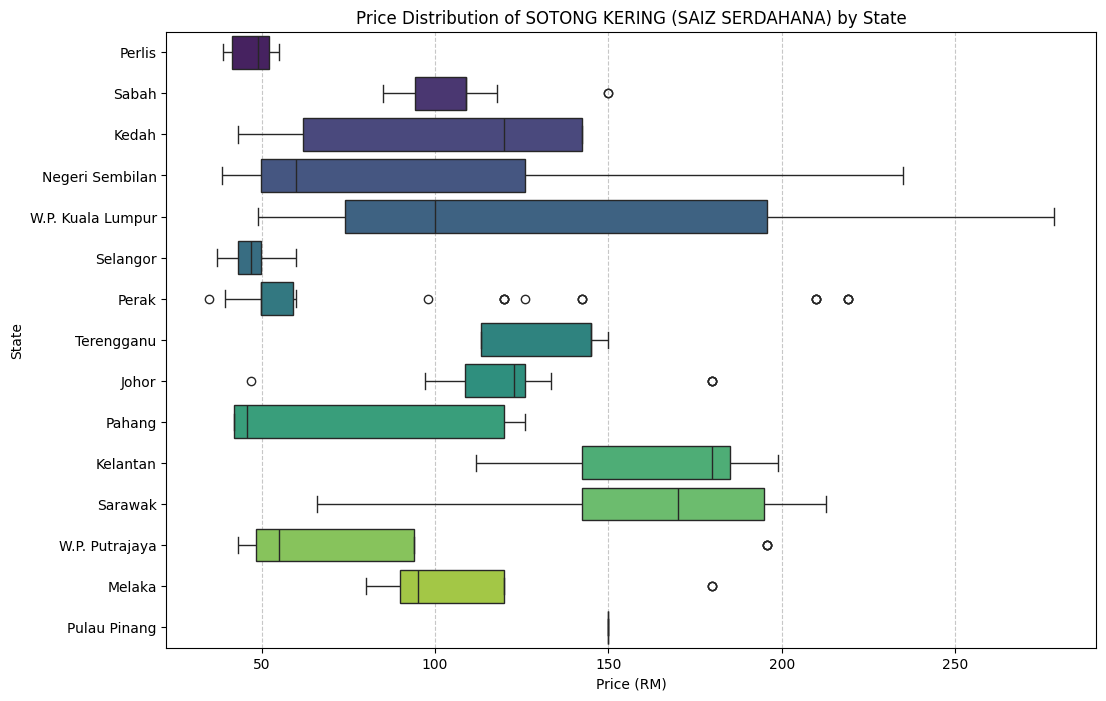

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for one specific item to keep the chart clean
target_item = 'SOTONG KERING (SAIZ SERDAHANA)'
df_item = df[df['item'] == target_item]

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_item, x='price', y='state', hue='state', palette='viridis', legend=False)

plt.title(f'Price Distribution of {target_item} by State')
plt.xlabel('Price (RM)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

c:\Users\WengSoon\Desktop\Studies\Self\SQL\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


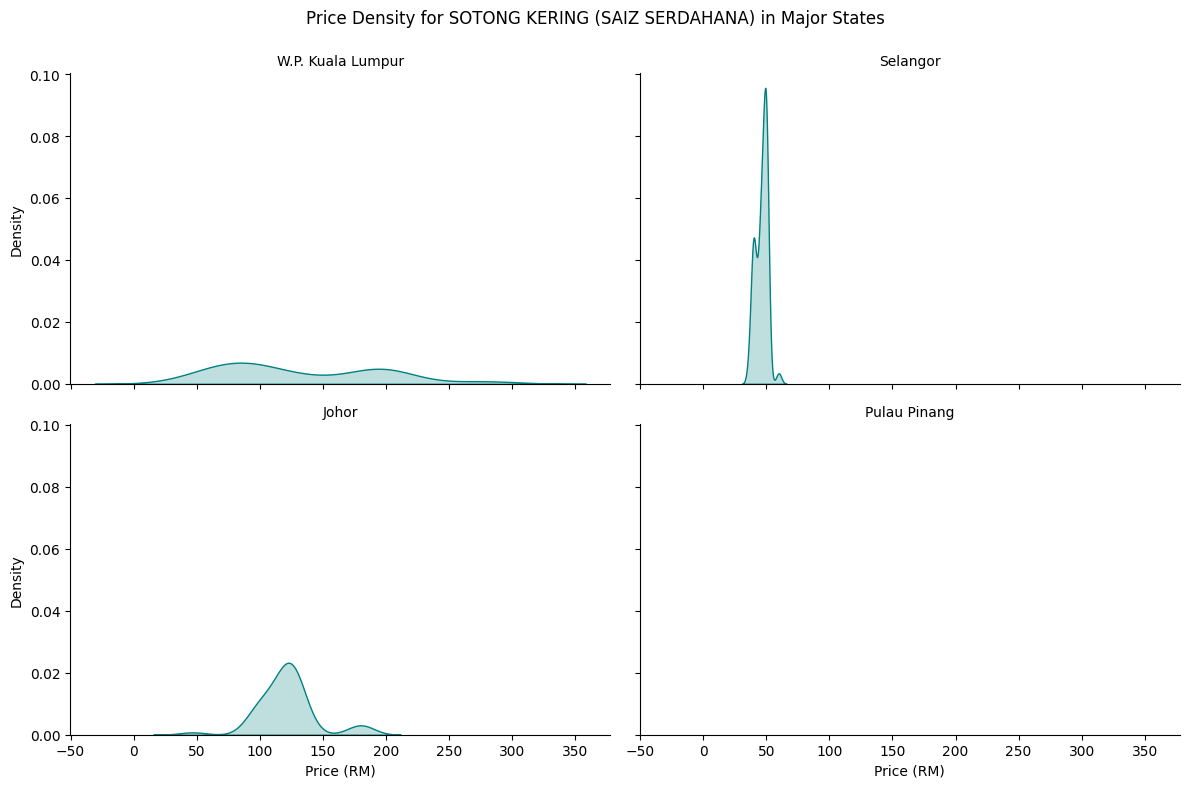

In [4]:
# Select a few major states to avoid making the chart too small
major_states = ['Selangor', 'W.P. Kuala Lumpur', 'Johor', 'Pulau Pinang']
df_sub = df_item[df_item['state'].isin(major_states)]

g = sns.FacetGrid(df_sub, col="state", col_wrap=2, height=4, aspect=1.5)
g.map(sns.kdeplot, "price", fill=True, color="teal")

g.set_axis_labels("Price (RM)", "Density")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.figure.suptitle(f'Price Density for {target_item} in Major States')
plt.show()

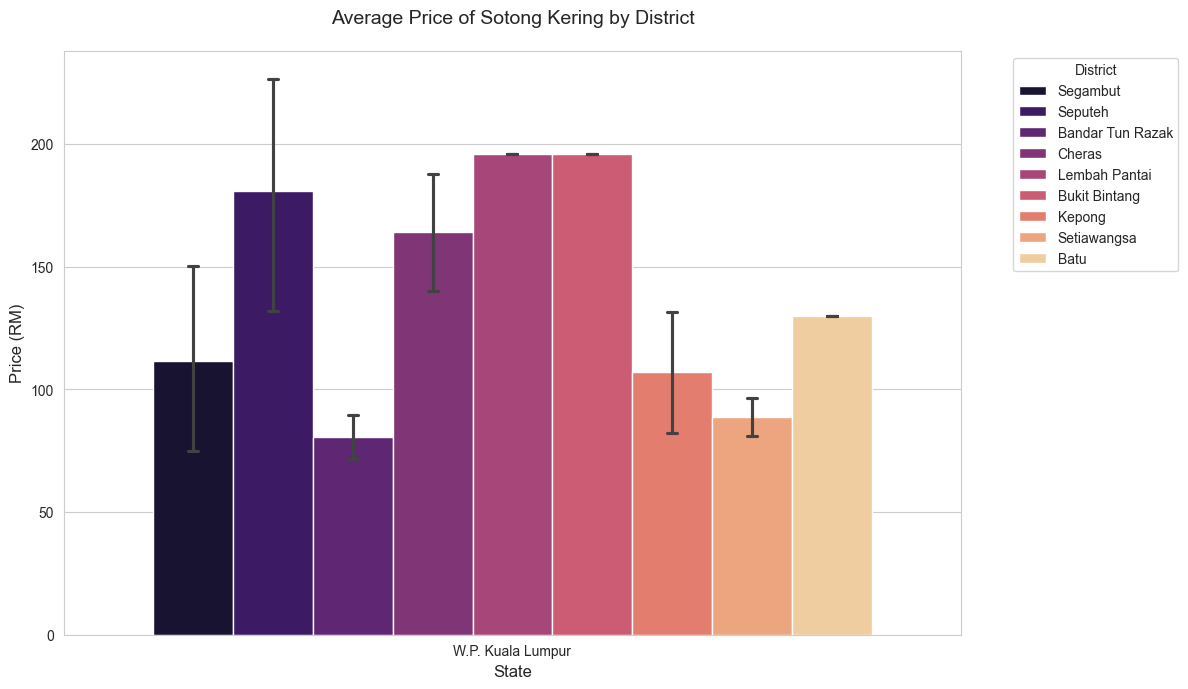

In [5]:
# 1. Filter and ensure we are using the normalized price
listed_states = ['W.P. Kuala Lumpur']
df_sub = df_item[df_item['state'].isin(listed_states)].copy()

# 2. Improve the visual aesthetics
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Create the Bar Plot
sns.barplot(
    data=df_sub, 
    x='state', 
    y='price',
    hue='district', 
    palette='magma',
    capsize=.1
)

# 4. Add labels and a more professional title
plt.title("Average Price of Sotong Kering by District", fontsize=14, pad=20)
plt.ylabel("Price (RM)", fontsize=12)
plt.xlabel("State", fontsize=12)
plt.legend(title="District", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()